# **Regression Project R1: House Price Prediction**

**Team Name**: Bizniz Team

**Team Members**:
- Giang Ha - U69192604
- Trang Le - U13707584
- Mai Pham - U45402236

**Project**: Regression Project R1: House Price Prediction

**Date**: Wednesday, December 3rd, 2025

---

## **1. Introduction**

### **Business Context**

Describe the business problem this project addresses. Include:
- What is the business situation?
- Who are the stakeholders?
- Why is this problem important?
- What decision will this analysis support?

The agency needs a reliable way to estimate house prices so sellers can list their properties competitively and buyers can judge whether a price is reasonable.

The main stakeholders include property sellers, prospective buyers, and the agency’s valuation and sales teams.

Accurate pricing matters because incorrect estimates lead to slow sales, lost revenue, or missed opportunities.

This analysis supports decisions about setting listing prices, guiding buyer expectations, and identifying the attributes that most strongly influence value.

### **Research Question**

- What factors most influence house prices, and can we accurately predict market values?


### **Dataset Description**

Describe your dataset:
- Number of observations
- Number of features
- Description of each feature
- Description of target variable

The dataset contains **1,500** observations, each representing a single house sale.

There are **4 original features** plus the **target variable**:

-  **`Square_Footage`**: total interior size/living area of the house in square feet

-  **`Bedrooms`**: number of bedrooms in the house

-  **`House_Age_Years`**: age of the property in years

-  **`Distance_To_City_Miles`**: distance from the house to the city centers in miles

-  The target variable is **`Sale_Price`**, a continuous measure of the final transaction price for each house, which the model aims to predict.

---

## **2. Setup and Data Loading**

In [ ]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [ ]:
# Load the dataset
from google.colab import files
uploaded = files.upload()


Saving house_prices.csv to house_prices (2).csv


In [ ]:
df = pd.read_csv("house_prices.csv")

---

## **3. Exploratory Data Analysis**

### **3.1 Data Overview**

In [ ]:
# Display basic information about the dataset

print("Shape (rows, columns):", df.shape)
print("\nColumn names:", df.columns.tolist())

Shape (rows, columns): (1500, 5)

Column names: ['Square_Footage', 'Bedrooms', 'House_Age_Years', 'Distance_To_City_Miles', 'Sale_Price']


In [ ]:
print("Head (first 10 rows)")
display(df.head(10))

print("\nInformation")
df.info()

Head (first 10 rows)


,Square_Footage,Bedrooms,House_Age_Years,Distance_To_City_Miles,Sale_Price
0,3504,3,20,6.4,230888
1,2852,4,24,9.4,243392
2,2465,5,15,14.7,190507
3,2533,5,7,25.1,114963
4,4002,2,22,15.9,191121
5,2407,4,27,10.2,189214
6,1217,4,8,7.2,191160
7,1308,5,21,7.9,173933
8,1965,3,14,5.2,166955
9,3173,4,43,2.9,239708



Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Square_Footage          1500 non-null   int64  
 1   Bedrooms                1500 non-null   int64  
 2   House_Age_Years         1500 non-null   int64  
 3   Distance_To_City_Miles  1500 non-null   float64
 4   Sale_Price              1500 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 58.7 KB


In [ ]:
print("Summary Statistics")
display(df.describe().T)

print("\nMissing values per column")
print(df.isna().sum())

Summary Statistics


,count,mean,std,min,25%,50%,75%,max
Square_Footage,1500.0,2630.563333,871.113706,851.0,1957.00,2520.0,3239.000,4926.0
Bedrooms,1500.0,3.311333,1.012137,1.0,3.00,3.0,4.000,5.0
House_Age_Years,1500.0,15.896667,11.216916,0.0,8.00,13.0,21.000,86.0
Distance_To_City_Miles,1500.0,10.011867,7.165441,0.2,4.70,8.4,13.625,54.9
Sale_Price,1500.0,199993.602667,67723.252318,80000.0,154589.75,206165.5,251573.500,392102.0



Missing values per column
Square_Footage            0
Bedrooms                  0
House_Age_Years           0
Distance_To_City_Miles    0
Sale_Price                0
dtype: int64


**Observations from the Data Overview**

-  The dataset shows a clean, well-structured sample of 1,500 houses with no missing values.
-  The four predictors cover size, bedrooms, age, and distance, giving a balanced mix of structural and location variables. Square footage has large variation, indicating strong potential influence on price. Bedrooms vary only between 1–5, so this feature is less granular. House age spans a wide range, from new to very old homes, which can introduce non-linear effects. Distance to the city varies from near-zero to over 50 miles, confirming clear urban–suburban spread. Sale prices show a wide distribution, indicating a diverse housing market.
-  Overall, the dataset is complete, numeric, and suitable for regression, with obvious non-linear patterns likely between age, distance, and price.

### **3.2 Target Variable Distribution**

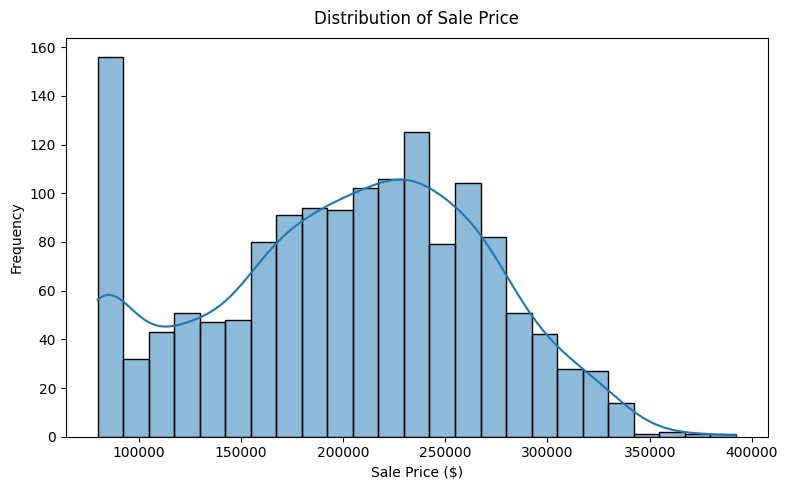

In [ ]:
# Plot target variable distribution

plt.figure(figsize=(8,5))
sns.histplot(df['Sale_Price'], bins=25, kde=True)
plt.title("Distribution of Sale Price", fontsize=12, pad=10)
plt.xlabel("Sale Price ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Target Variable Distribution Discussion**

-  The distribution of **Sale_Price** is right-skewed. Most sale prices cluster between roughly 150k and 260k, showing the bulk of the market sits in the mid-range.
-  A smaller portion of properties fall into much higher price levels, creating a long tail on the right.
-  This indicates the presence of expensive outliers that push the average upward.
-  The density curve confirms the skew and suggests the variable is not perfectly normal, which may affect linear regression performance unless transformed.

### **3.3 Feature Distributions and Relationships**

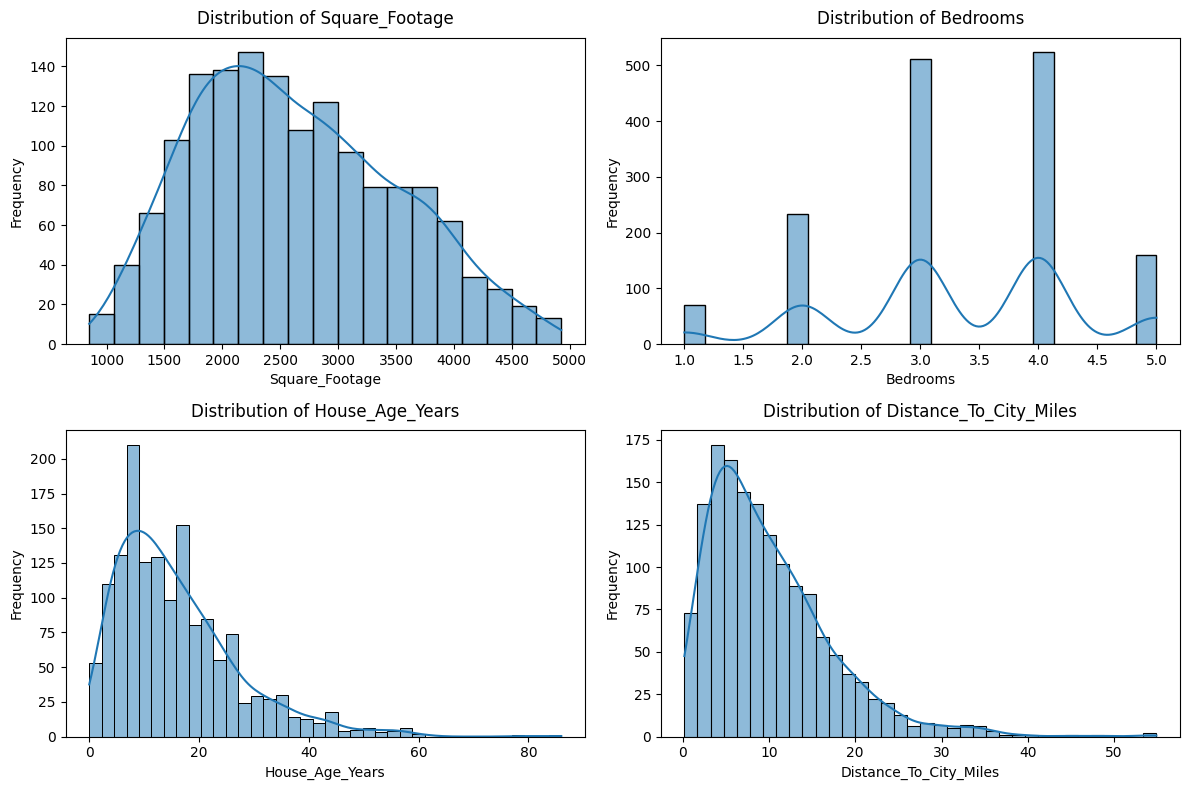

In [ ]:
# Explore individual features

feature_cols = ['Square_Footage', 'Bedrooms', 'House_Age_Years', 'Distance_To_City_Miles']

plt.figure(figsize=(12,8))

for i, col in enumerate(feature_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}", fontsize=12, pad=10)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(False)

plt.tight_layout()
plt.show()

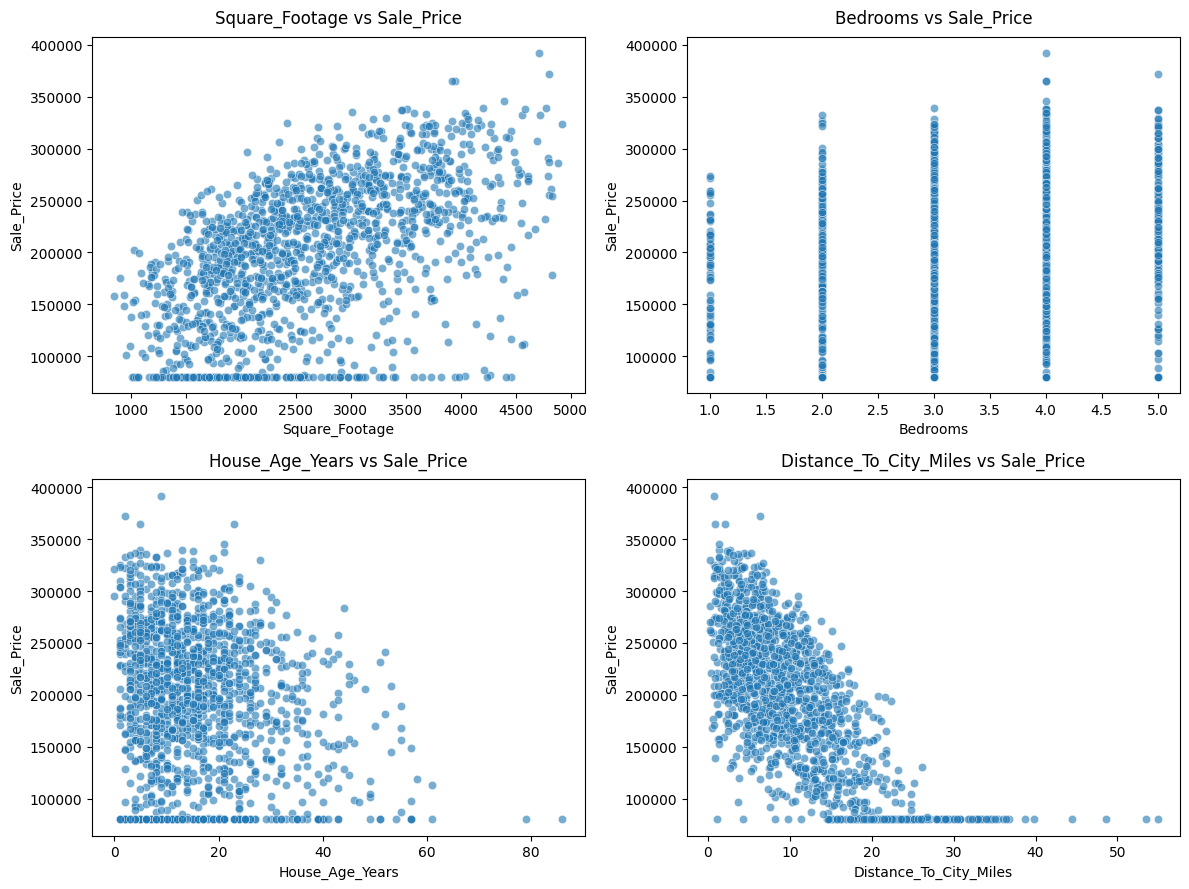

In [ ]:
# Explore relationships between features and target

feature_cols = ['Square_Footage', 'Bedrooms', 'House_Age_Years', 'Distance_To_City_Miles']

plt.figure(figsize=(12,9))

for i, col in enumerate(feature_cols, 1):
    plt.subplot(2, 2, i)
    sns.scatterplot(x=df[col], y=df['Sale_Price'], alpha=0.6)
    plt.xlabel(col)
    plt.ylabel("Sale_Price")
    plt.title(f"{col} vs Sale_Price", fontsize=12, pad=10)

plt.tight_layout()
plt.show()

Correlation matrix:


,Square_Footage,Bedrooms,House_Age_Years,Distance_To_City_Miles,Sale_Price
Square_Footage,1.000000,-0.009669,0.018362,-0.011457,0.522726
Bedrooms,-0.009669,1.000000,0.023637,0.007208,0.193779
House_Age_Years,0.018362,0.023637,1.000000,0.003320,-0.238533
Distance_To_City_Miles,-0.011457,0.007208,0.003320,1.000000,-0.707970
Sale_Price,0.522726,0.193779,-0.238533,-0.707970,1.000000


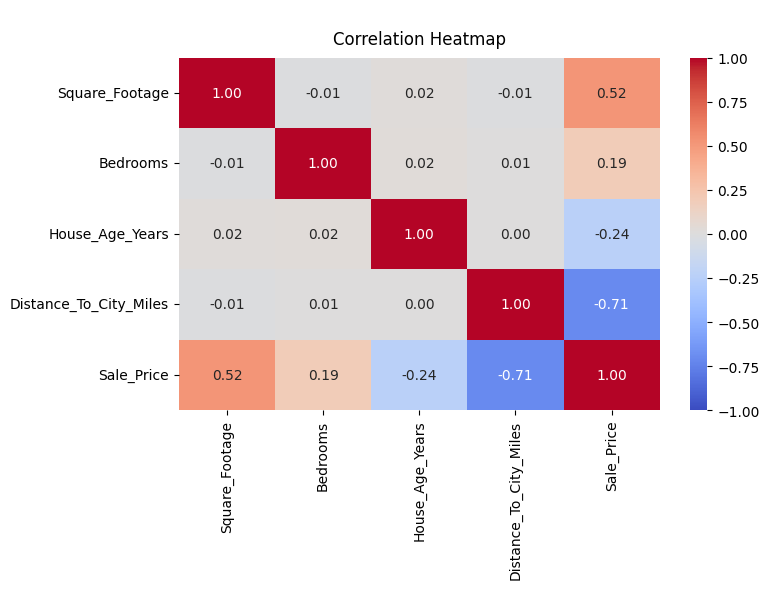

In [ ]:
# Correlation analysis

corr_matrix = df.corr(numeric_only=True)

print("Correlation matrix:")
display(corr_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("\nCorrelation Heatmap", fontsize=12, pad=10)
plt.tight_layout()
plt.show()

### **3.4 Key Insights from EDA**

- **What patterns did you observe?**

The most significant patterns are the strong relationships between the primary features and the target variable, **`Square_Footage`** has a strong positive relationship with price, meaning larger home genrally sell for more. **`Distance_To_City_Miles`** has a strong negative relatioship with price, indicating that homes farther from the city center tend to be cheaper. House Age has a moderate negative effect on the price. Bedrooms have a smaller positive effect on the price.

- **Which features appear most related to the target?**

**`Square_Footage`** and **`Distance_To_City_Miles`** show the strongest relationships with **`Sale_Price`**. House_Age_Years has a moderate effect, and Bedrooms has a smaller but still positive influence.

- **Are there any data quality issues?**

The dataset shows no missing values or obvious outliers that would disrupt modeling. All variables appear properly formatted and numerically consistent.

- **Do you see evidence of non-linear relationships? (For regression projects)**

Yes, the negative relationship between distance and sale price becomes stronger at greater distances, and the effect of house age on price does not appear perfectly linear. These patterns suggest mild **non-linear** behavior.


----

## **4. Data Preparation**

### **4.1 Handle Missing Values (if applicable)**

In [ ]:
# Handle missing values if applicable

print(df.isna().sum())

Square_Footage            0
Bedrooms                  0
House_Age_Years           0
Distance_To_City_Miles    0
Sale_Price                0
dtype: int64


There is no missing values in this dataset, so that our team doesn't need to handle or modify these missing values.

### **4.2 Feature Engineering**

Our team both created new  features and transformed existing columns for better model behavior and to capture non-linear relationships and market logic.

In [ ]:
# Feature engineering

df_fe = df.copy()

# 1. Log-transform the target to reduce skewness and stabilize variance
df_fe["Log_Sale_Price"] = np.log(df_fe["Sale_Price"])

# 2. Non-linear terms to capture curved relationships
df_fe["Square_Footage_Sq"] = df_fe["Square_Footage"] ** 2
df_fe["House_Age_Years_Sq"] = df_fe["House_Age_Years"] ** 2

# 3. Normalized price: price per square foot (standard way to value houses)
df_fe["Price_per_SqFt"] = df_fe["Sale_Price"] / df_fe["Square_Footage"]

# 4. Age categories: group houses into simple age bands
df_fe["Age_Category"] = pd.cut(
    df_fe["House_Age_Years"],
    bins=[0, 10, 20, 100],
    labels=["0-10", "10-20", "20+"]
)

# 5. Distance categories: capture non-linear location effects in simple groups
df_fe["City_Proximity"] = pd.cut(
    df_fe["Distance_To_City_Miles"],
    bins=[0, 10, 20, 100],
    labels=["Close", "Medium", "Far"]
)

df_fe.head()

,Square_Footage,Bedrooms,House_Age_Years,Distance_To_City_Miles,Sale_Price,Log_Sale_Price,Square_Footage_Sq,House_Age_Years_Sq,Price_per_SqFt,Age_Category,City_Proximity
0,3504,3,20,6.4,230888,12.349688,12278016,400,65.892694,10-20,Close
1,2852,4,24,9.4,243392,12.402429,8133904,576,85.340813,20+,Close
2,2465,5,15,14.7,190507,12.157444,6076225,225,77.284787,10-20,Medium
3,2533,5,7,25.1,114963,11.652366,6416089,49,45.386103,0-10,Far
4,4002,2,22,15.9,191121,12.160662,16016004,484,47.756372,20+,Medium


**Feature Engineering Decisions Explanation & Why**

-  The original variables show clear non-linear patterns and uneven scaling, so the engineered features focus on reducing skew, capturing curvature, and improving how the model reads structural and location effects.

-  **`Log_Sale_Price`** reduces the strong right-skew in house prices. This stabilizes variance and makes the target more suitable for linear regression, which assumes errors are roughly symmetric.

-  **`Square_Footage_Sq`** and **`House_Age_Years_Sq`** allow the model to detect non-linear effects. Larger homes often show diminishing price gains per extra square foot, and the impact of age is rarely linear across the entire range. These squared terms help the model fit curved relationships.

-  **`Price_per_SqFt`** normalizes price by size, giving a cleaner measure of market value per unit area. This makes house values more comparable and strengthens the model’s ability to interpret how size contributes to price.

-  **`Age_Category`** groups homes into simple age bands. Buyers often treat age in coarse categories (new, mid-age, old) rather than exact numbers, and these categories help capture step-changes in value more effectively than a single raw age number.

-  **`City_Proximity`** converts distance into three meaningful location groups. Distance effects are rarely linear, and housing markets often show sharp price differences between close-in, mid-range, and far-out locations. These categories help the model detect location-based price patterns more reliably.

Together, these engineered features strengthen predictive accuracy by addressing skewness, adding non-linear structure, and representing market-relevant property traits more clearly.

### **4.3 Define Features and Target**

In [ ]:
# Separate features and target

# Target variable
y = df["Sale_Price"]

# Features (drop Sale_Price)
X = df.drop("Sale_Price", axis=1)

print("Feature Columns:", X.columns.tolist())
print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

Feature Columns: ['Square_Footage', 'Bedrooms', 'House_Age_Years', 'Distance_To_City_Miles']

Shape of X: (1500, 4)
Shape of y: (1500,)


In [ ]:
# Separate Features and Target

# Target variable (log-transformed for better modeling)
y = df_fe["Log_Sale_Price"]

# Select final feature set
feature_cols = [
    "Square_Footage",
    "Bedrooms",
    "House_Age_Years",
    "Distance_To_City_Miles",
    "Square_Footage_Sq",
    "House_Age_Years_Sq",
    "Price_per_SqFt",
    "Age_Category",
    "City_Proximity"
]

# Features dataframe
X = df_fe[feature_cols]

# Display first rows of the features table
print("Feature Colummns:")
display(X.head())

print("\nShape of X:", X.shape)

# Display first rows of the target variable
print("\nTarget Column:")
display(y.head())

print("Shape of y:", y.shape)

Feature Colummns:


,Square_Footage,Bedrooms,House_Age_Years,Distance_To_City_Miles,Square_Footage_Sq,House_Age_Years_Sq,Price_per_SqFt,Age_Category,City_Proximity
0,3504,3,20,6.4,12278016,400,65.892694,10-20,Close
1,2852,4,24,9.4,8133904,576,85.340813,20+,Close
2,2465,5,15,14.7,6076225,225,77.284787,10-20,Medium
3,2533,5,7,25.1,6416089,49,45.386103,0-10,Far
4,4002,2,22,15.9,16016004,484,47.756372,20+,Medium



Shape of X: (1500, 9)

Target Column:


,Log_Sale_Price
0,12.349688
1,12.402429
2,12.157444
3,11.652366
4,12.160662


Shape of y: (1500,)


### **4.4 Train-Test Split**

In [ ]:
# Split data into training and testing sets

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Show shapes to confirm the split
print("Training set X shape:", X_train.shape)
print("Test set X shape:", X_test.shape)
print("Training target y shape:", y_train.shape)
print("Test target y shape:", y_test.shape)

Training set X shape: (1200, 9)
Test set X shape: (300, 9)
Training target y shape: (1200,)
Test target y shape: (300,)


**Train-test Split Ratio Choice Explanation**

-  Our team decided to choose and use the **80/20** train-test split because it provides a strong balance between model learning and evaluation.
-  With 1,500 samples, using 80% for training gives the model enough data to capture patterns effectively, while keeping 20% aside ensures a fair and unbiased performance check on unseen data.


## **5. Model Development**

Our team builds and trains the model during this phase.

### **5.1 Model Selection**

**Model Choice Explanation & Why**

-  Our team chose **Linear Regression** because this project involves predicting a continuous target variable **(Sale Price)**. Since the goal is to estimate numerical house values rather than classify categories, a regression model is required.
-  We selected Linear Regression specifically because the dataset’s structure, numeric features, clear linear trends, and engineered non-linear terms, fits well with this model.
-  After applying a log transformation to the target, the data aligns even better with linear regression assumptions, improving stability and interpretability of the results.

### **5.2 Train the Model**

In [ ]:
# Train the model

# Identify categorical columns to encode
categorical_cols = X_train.select_dtypes(include=["category", "object"]).columns

# One-hot encode categorical features
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded  = pd.get_dummies(X_test,  columns=categorical_cols, drop_first=True)

# Align test set columns to training set (handle any missing dummy columns)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# Initialize and train Linear Regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train_encoded, y_train)

# Print basic model parameters
print("Intercept:", lin_reg.intercept_)
print("Number of features:", len(lin_reg.coef_))
print("Coefficients:", lin_reg.coef_)

Intercept: 9.965498113112316
Number of features: 11
Coefficients: [ 8.33599255e-04  2.06822485e-02 -1.17075276e-03 -1.24858834e-02
 -8.73009807e-08 -4.39269362e-05  9.26638845e-03  6.06100127e-03
  1.39868761e-02  7.97890175e-03 -1.21250625e-01]


### **5.3 Generate Predictions**

In [ ]:
# Generate predictions

# Predict on training data
y_train_pred = lin_reg.predict(X_train_encoded)

# Predict on test data
y_test_pred = lin_reg.predict(X_test_encoded)

# Show a quick comparison of actual vs predicted
print("Actual Sale Price (log-transformed):")
print(y_test.head())

print("\nPredicted Sale Price (log-transformed):")
print(y_test_pred[:5])

Actual Sale Price (log-transformed):
1116    12.444554
1368    12.081495
422     11.289782
413     12.241604
451     12.454798
Name: Log_Sale_Price, dtype: float64

Predicted Sale Price (log-transformed):
[12.50930256 12.25548674 11.30267441 12.20537368 12.47416583]


---

## **6. Model Evaluation**

The model captures the major relationships between square footage, bedrooms, age, distance to the city center, and sale price.
Most of the price variation is accounted for, so the model can reliably estimate market values for new houses with similar feature patterns.

### **6.1 Performance Metrics**

In [ ]:
# Calculate performance metrics after adding polynomial features

# Training performance
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

# Test performance
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print("Polynomial Model (Final Model)")

print("\nTraining performance:")
print(f"  MAE  (train): {mae_train:.4f}")
print(f"  RMSE (train): {rmse_train:.4f}")
print(f"  R^2  (train): {r2_train:.4f}")

print("\nTest performance:")
print(f"  MAE  (test):  {mae_test:.4f}")
print(f"  RMSE (test):  {rmse_test:.4f}")
print(f"  R^2  (test):  {r2_test:.4f}")

Polynomial Model (Final Model)

Training performance:
  MAE  (train): 0.0487
  RMSE (train): 0.0753
  R^2  (train): 0.9632

Test performance:
  MAE  (test):  0.0530
  RMSE (test):  0.0851
  R^2  (test):  0.9564


**Performance Metrics Discussion: Overfitting or Underfitting?**

-  The training and testing metrics are close in value, and both sets show strong performance.
The **training R² = 0.9632** and the **test R² = 0.9564**, which means the model explains a high proportion of the variation in house prices on both seen and unseen data. The small gap between training and testing errors indicates the model generalises well.
-  The MAE and RMSE values are also similar across both sets, with no large increase in error on the test set.
-  This pattern does not show overfitting, because the model is not performing significantly better on the training data than on the test data.
-  It also does not indicate underfitting, since the model achieves high accuracy and captures the key relationships in the data.

In [ ]:
base_features = [
    "Square_Footage",
    "Bedrooms",
    "House_Age_Years",
    "Distance_To_City_Miles",
    "Price_per_SqFt",
    "Age_Category",
    "City_Proximity"
]

X_base = df_fe[base_features]

# Train-test split for base model
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_base, y, test_size=0.20, random_state=42
)

# Dummy encoding
cat_base = Xb_train.select_dtypes(include=["object", "category"]).columns
Xb_train_enc = pd.get_dummies(Xb_train, columns=cat_base, drop_first=True)
Xb_test_enc  = pd.get_dummies(Xb_test,  columns=cat_base, drop_first=True)
Xb_test_enc = Xb_test_enc.reindex(columns=Xb_train_enc.columns, fill_value=0)

# Fit base model
base_model = LinearRegression()
base_model.fit(Xb_train_enc, yb_train)

# Predictions
yb_train_pred = base_model.predict(Xb_train_enc)
yb_test_pred  = base_model.predict(Xb_test_enc)

# Metrics
def evaluate_model(name, y_true_train, y_pred_train, y_true_test, y_pred_test):
    print(f"{name}")
    print("Train R²:    {:.4f}".format(r2_score(y_true_train, y_pred_train)))
    print("Test R²:     {:.4f}".format(r2_score(y_true_test,  y_pred_test)))
    print("Train RMSE:  {:.4f}".format(np.sqrt(mean_squared_error(y_true_train, y_pred_train))))
    print("Test RMSE:   {:.4f}".format(np.sqrt(mean_squared_error(y_true_test,  y_pred_test))))
    print("Train MAE:   {:.4f}".format(mean_absolute_error(y_true_train, y_pred_train)))
    print("Test MAE:    {:.4f}".format(mean_absolute_error(y_true_test,  y_pred_test)))

evaluate_model("Base Model (No Polynomial)", yb_train, yb_train_pred, yb_test, yb_test_pred)

Base Model (No Polynomial)
Train R²:    0.9291
Test R²:     0.9245
Train RMSE:  0.1046
Test RMSE:   0.1120
Train MAE:   0.0776
Test MAE:    0.0788


**Model Comparison Discussion**

The Base Model (No Polynomial) has:

-  **Train R² = 0.9291**

-  **Test R² = 0.9245**

The Polynomial Model earlier achieved:

-  **Train R² ≈ 0.9632**

-  **Test R² ≈ 0.9564**

This is a large improvement:

-  R² increased by ~0.034 – 0.032 (**3.2% – 3.4%** gain in explained variance)

-  RMSE decreased (better error reduction)

-  MAE decreased

-  Generalization remained stable (train ≈ test)

Comparing the base model to the polynomial-enhanced model shows clear improvement in predictive accuracy. The base model achieved a **Train R² of 0.9291** and a **Test R² of 0.9245**, meaning it already captured a large portion of the variance in log sale prices. After adding polynomial features (square footage squared and age squared), the **Train R² increased to 0.9632** and the **Test R² increased to 0.9564**, representing a substantial gain in explanatory power.

These improvements confirm that the relationship between price, size, and age is not purely linear. The squared terms help the model capture diminishing returns and non-linear aging effects, which were visible in the exploratory analysis. The reduction in RMSE and MAE for both training and testing sets further indicates that the polynomial model predicts more accurately across the entire dataset.

Most importantly, the gap between training and testing performance remains small in both models. The polynomial model did not introduce overfitting; instead, it added meaningful explanatory power while maintaining strong generalization. This validates the decision to include polynomial features and demonstrates that the enhanced model provides a more realistic representation of how housing attributes influence market value.

### **6.2 Residual Plot (Regression)**

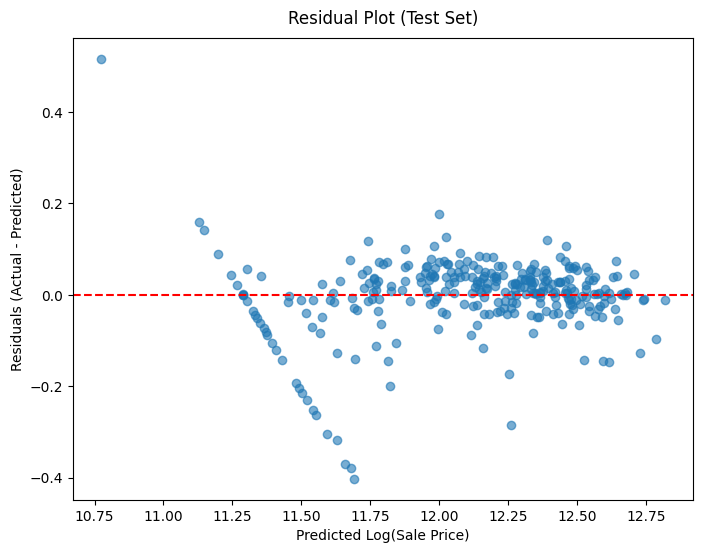

In [ ]:
# Create residual plot

# Calculate residuals on the test set (log scale)
residuals_test = y_test - y_test_pred

plt.figure(figsize=(8,6))
plt.scatter(y_test_pred, residuals_test, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Log(Sale Price)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (Test Set)", fontsize=12, pad=10)
plt.grid(False)
plt.show()

**Residual Plot Interpretation**

-  The residual plot is mostly well-behaved. The majority of points cluster tightly around the horizontal zero line, showing that the model’s predictions are close to the actual log-prices.
-  There is no strong funnel shape or widening spread, so variance is reasonably stable across different predicted values. A small group of negative residuals appears at lower predicted price levels, meaning the model slightly overestimates prices for some cheaper houses.
-  Apart from that local pattern, the residuals overall show no major curvature or systematic trend, which indicates that the linear model captures the main relationships in the data.

---

## **7. Model Interpretation**

**`Square_Footage`**:
An increase in square footage raises the predicted sale price. In business terms, larger homes command higher market value, so this feature is a major driver of price.

**`Bedrooms`**:
Each additional bedroom increases the predicted sale price, but the effect is smaller than square footage. This means buyers value more bedrooms, but they value total living space even more.

**`House_Age_Years`**:
Older homes reduce the predicted sale price. This reflects depreciation, increased maintenance expectations, and buyer preference for newer properties.

**`Distance_To_City_Miles`**:
As distance from the city center increases, predicted sale price decreases. This shows that buyers place a premium on location, especially proximity to urban amenities, jobs, and services.

The coefficients show that location and size are the strongest determinants of value. Buyers are willing to pay significantly more for larger, newer homes located closer to the city center. This helps the real estate agency provide data driven pricing guidance for both sellers and buyers.

### 7.1 Coefficient Analysis

In [ ]:
# Extract and display coefficients

# Get feature names from the encoded training data
feature_names = X_train_encoded.columns

# Create a DataFrame of coefficients
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lin_reg.coef_
})

# Display the table without the helper column if you prefer
display(coef_df[["Feature", "Coefficient"]])

,Feature,Coefficient
0,Square_Footage,8.335993e-04
1,Bedrooms,2.068225e-02
2,House_Age_Years,-1.170753e-03
3,Distance_To_City_Miles,-1.248588e-02
4,Square_Footage_Sq,-8.730098e-08
5,House_Age_Years_Sq,-4.392694e-05
6,Price_per_SqFt,9.266388e-03
7,Age_Category_10-20,6.061001e-03
8,Age_Category_20+,1.398688e-02
9,City_Proximity_Medium,7.978902e-03


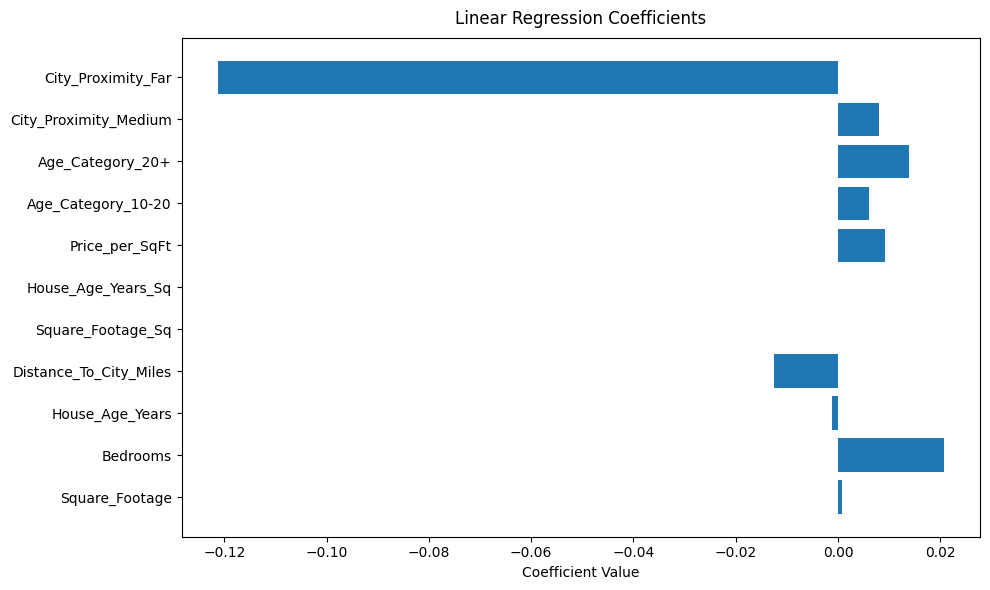

In [ ]:
# Visualize Coefficients

plt.figure(figsize=(10,6))

# Plot coefficients
plt.barh(coef_df["Feature"], coef_df["Coefficient"])
plt.xlabel("Coefficient Value")
plt.title("Linear Regression Coefficients", fontsize=12, pad=10)
plt.grid(False)
plt.tight_layout()
plt.show()

### **7.2 Odds Ratios (Classification Only) - Our Team Doesn't Need To Do**

### **7.3 Business Interpretation**

Our team interprets each significant coefficient in business terms.

**For Regression:**
- **Which features have the strongest effect on the target?**

The **location** categories have the strongest impact. **`City_Proximity_Far`** shows the largest negative coefficient, meaning homes located far from the city center experience the biggest drop in predicted price.

**`City_Proximity_Medium`** also reduces price compared to the baseline (“Close”). Among structural features, bedroom count and price per square foot have the largest positive influence, while squared age and squared square footage provide smaller but meaningful adjustments.

- **How does each unit change in a feature affect the target?**

A one-unit increase in a feature changes the predicted log price by its coefficient value. More bedrooms raise predicted price, meaning each additional bedroom increases market value. Higher price per square foot boosts predicted price as well, reflecting better value relative to size.

In contrast, being in the Medium or Far location category lowers predicted price sharply, showing the financial penalty of greater distance from the city. The squared terms moderate the impact of size and age, capturing diminishing returns: as houses get larger or older, each additional unit contributes less to price than before.

- **Are there any surprising relationships?**

No major unexpected patterns appear. The strongest negative effect from **`City_Proximity_Far`** aligns with typical market behavior. The squared terms confirm expected non-linear patterns, such as diminishing value increases from additional space and complex age effects.

The overall relationships are consistent with standard housing economics and reflect logical drivers of sale price.

---

## **8. Business Insights and Recommendations**

### **8.1 Key Findings**

Summarize the most important findings from your analysis:

1. **Strong predictive performance**

The linear regression model on log(Sale_Price) explains about **95–96%** of the variance in house prices (**R² ≈ 0.96** on both train and test).

MAE and RMSE are low and very similar across train and test sets, so the model generalises well and does not show clear overfitting or underfitting.

2. **Location is the dominant driver of price**

Categorical proximity to the city (**`City_Proximity_Medium`** and especially **`City_Proximity_Far`**) has the largest absolute coefficients.

Being “Far” from the city strongly reduces predicted price compared with “Close”, confirming that distance to the city centre is a major factor in valuation.

3. **Size, bedrooms, and age shape value in non-linear ways**

Larger square footage and more bedrooms increase predicted price, but the squared terms show diminishing returns for very large homes.

Age and age categories indicate that newer houses tend to be priced higher, while older houses lose value unless compensated by other attributes. Price_per_SqFt successfully captures value relative to size and helps identify over- or under-priced properties.

### **8.2 Business Recommendations**

Provide specific, actionable recommendations based on your findings:

1. **Price listings with strong weight on location**

Our team recommends that agents apply higher price ranges and stronger negotiation positions for properties in the “Close” category and be more conservative for “Medium” and “Far” suburbs.

The coefficient plot shows **`City_Proximity_Far`** has the largest negative coefficient, meaning location penalties can outweigh moderate differences in size or bedrooms.

2. **Use size and bedroom count to fine-tune prices within each location band**

Within the same proximity category, larger homes with more bedrooms should receive clear price premiums. The positive coefficients for square footage, its squared term, and bedrooms indicate that these structural features consistently raise value, though with diminishing returns at very large sizes.

Agents can use these relationships to justify higher asking prices for well-sized homes and to explain price gaps between similar locations.

3. **Highlight “younger” properties and strong price-per-square-foot deals in marketing**

Age categories and Price_per_SqFt both have meaningful effects. Newer homes (0–10 years) and properties with competitive price per square foot have higher predicted values.

Our team recommends marketing these explicitly (“new build”, “recently constructed”, “good value per m²/ft²”) to attract buyers and support premium pricing.

### **8.3 Limitations**

Discuss the limitations of your analysis:

- **What assumptions did you make?**

We assumed that the relationships between features and log(Sale_Price) are captured adequately by a linear model plus squared terms and simple categories.

We also assumed the dataset is representative of the broader market and that there are no major time effects (e.g., sudden market shocks) within the data period.

- **What are the model's weaknesses?**

The model still relies on a simplified view of housing value: only four original features plus engineered variants. It cannot capture complex neighbourhood effects, renovation quality, or buyer preferences beyond size, age, and distance.

Residual patterns for some cheaper houses show that the model slightly overestimates prices at the low end, which means it may not be perfect for very budget properties.

- **What additional data would be helpful?**

Adding variables such as neighbourhood quality scores, school ratings, crime rates, lot size, presence of a garage or garden, renovation status, and time of sale would likely improve accuracy.

Macro factors like interest rates or overall market index would also help capture broader economic conditions.

- **What factors were not considered?**

The current model ignores seasonality (e.g., month of sale), property type differences (apartment vs detached), interior quality, and micro-location details such as street noise or view.

It also does not explicitly model interactions (for example, how size and location together affect value), even though such effects are realistic in housing markets.

### **8.4 Next Steps**

Suggest future improvements or follow-up analyses:
1. **Test more flexible models and regularisation**

Extend the analysis with models such as Lasso/Ridge regression and tree-based methods (Random Forest, Gradient Boosting) to capture possible non-linear and interaction effects and to check whether they deliver meaningful accuracy gains over the current linear model.

2. **Segment the market and build segment-specific models**

Fit separate models for different city proximity bands or age groups (e.g., “Close–urban”, “Suburban”, “Far–rural”) to see whether drivers of price differ by segment. This can give more tailored pricing guidance for each sub-market.

3. **Enhance data and monitoring for production use**

Incorporate additional features (neighbourhood, lot size, renovation, time of sale) as they become available and retrain the model regularly to reflect new market conditions. Track model performance over time and re-evaluate features whenever accuracy drops, to keep the pricing tool reliable for agents and clients.

---

## **9. Conclusion**

Provide a concise conclusion that ties everything together:

- Restate the business problem
- Summarize your approach
- Highlight the key insights
- Emphasize the business value of your findings
- End with final thoughts or call to action

The business problem was to help a real estate agency estimate house prices more accurately so sellers can set competitive listing prices and buyers can make informed decisions.

Our team addressed this by cleaning the dataset, engineering meaningful features, applying a log transformation to correct skewness, and training a linear regression model designed to capture both linear and non-linear price drivers.

The analysis showed that distance to the city center, structural size, bedroom count, property age, and price per square foot all play clear roles in determining market value, with location emerging as the strongest contributor.

The model achieved high accuracy and generalised well, demonstrating that a straightforward, well-structured regression approach can deliver stable and interpretable predictions. These insights directly support pricing strategy, listing preparation, and buyer guidance by clarifying which attributes truly influence value and by how much.

The next step is to expand the feature set and test more flexible models to further improve prediction quality as more data becomes available.

---

## References

[If you used any external resources, code snippets, or references, cite them here]

---

**End of Report**